# 🍚 Cooked Rice Shelf Life Prediction — Full ML Pipeline
### Two-Model System: Status Classifier + RSL Regressor
---
**This notebook will train and evaluate two machine learning models:**

| Model | Input | Output | File saved |
|-------|-------|--------|------------|
| Status Classifier | 9 sensor readings | `Fresh` / `Spoiled` | `classifier.pkl` |
| RSL Regressor | 9 sensors + hours elapsed | Hours until complete spoilage | `regressor.pkl` |

**Data**: 5 batches of cooked rice sensor readings (sampled every ~5 minutes over ~16–23 hours each)

**Key principle**: ⚠️ No data leakage — Batch 5 is held out completely and never seen during training.

Batches **1, 2, 3, 4** are used for training (with Leave-One-Batch-Out cross-validation),
and Batch **5** is used only for the final, honest test.

---
> 📘 **New to machine learning?** Every section includes a plain-language explanation before the code. Read those first, then run the code cell by cell using **Shift + Enter**.


## 📦 Step 0: Install Required Packages
Run this cell first. If packages are already installed, it will do nothing.

In [1]:
# Uncomment and run if you don't have these installed:
# !pip install pandas numpy matplotlib seaborn scikit-learn joblib openpyxl

import pandas, numpy, sklearn, matplotlib, seaborn, joblib
print(f"pandas       {pandas.__version__}")
print(f"numpy        {numpy.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print(f"matplotlib   {matplotlib.__version__}")
print(f"seaborn      {seaborn.__version__}")
print("\n✅ All packages ready!")

pandas       2.2.3
numpy        2.2.2
scikit-learn 1.7.2
matplotlib   3.10.0
seaborn      0.13.2

✅ All packages ready!


## 📚 Step 1: Import Libraries & Define Constants

**What each library does:**
- `pandas` / `numpy` → manipulate tables of data
- `matplotlib` / `seaborn` → draw charts
- `scikit-learn` → machine learning models, evaluation, preprocessing
- `joblib` → save/load trained models (the `.pkl` files)

**Constants** you might want to adjust:
- `DATA_DIR` → folder containing your batch `.xlsx` files
- `TEST_BATCH` → which batch number to hold out for final testing (default: 5)
- `ROLL_WIN` → how many readings to smooth over (default: 5 = ~25 minutes)


In [2]:
import glob, os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)
import joblib

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Plot styling ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'         : 120,
    'figure.facecolor'   : 'white',
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.titlesize'     : 12,
    'axes.labelsize'     : 10,
})
sns.set_theme(style='whitegrid', font_scale=1.0)

# ── Constants — adjust these if needed ───────────────────────────────────────
DATA_DIR     = "data"     # ← folder with your .xlsx batch files (expects 5 files)
TEST_BATCH   = 5          # ← this batch is locked away for final testing
ROLL_WIN     = 5          # ← rolling window (5 readings ≈ 25 min)
SEED         = 42

# Only Fresh / Spoiled are labeled in this dataset (no Half_Spoiled)
LABEL_ORDER  = ['Fresh', 'Spoiled']
LABEL_COLORS = {'Fresh': '#27ae60', 'Spoiled': '#e74c3c'}
SENSOR_COLS  = ['temperature', 'humidity', 'mq2_ppm', 'mq3_ppm', 'mq4_ppm',
                'mq135_ppm', 'mq136_ppm', 'mq137_ppm', 'co2']

print(f"DATA_DIR   = '{DATA_DIR}'")
print(f"TEST_BATCH = {TEST_BATCH}  (held-out — never used during training)")
print(f"Training batches will be all other batches found (expected: 1, 2, 3, 4)")
print(f"ROLL_WIN   = {ROLL_WIN}   readings = ~{ROLL_WIN*5} minutes of smoothing")


DATA_DIR   = 'data'
TEST_BATCH = 5  (held-out — never used during training)
Training batches will be all other batches found (expected: 1, 2, 3, 4)
ROLL_WIN   = 5   readings = ~25 minutes of smoothing


## 📂 Step 2: Load & Explore the Data (EDA)

**EDA (Exploratory Data Analysis)** is always the first thing you do in ML. Before building any model, you need to *understand* what's in your data:
- How many readings per batch?
- How long does spoilage take?
- Do sensor values actually change as the rice spoils?

> ⚠️ **Label note**: Only two labels exist in this dataset — `Fresh` and `Spoiled`. Any stray hyphens (e.g. `"Fresh-ish"` typos) are normalised to underscores just in case, but no `Half_Spoiled` class is expected or used anywhere in this notebook.


In [3]:
# ── Load all batch .xlsx files ───────────────────────────────────────────────
files = sorted(glob.glob(os.path.join(DATA_DIR, "*.xlsx")))
print(f"Found {len(files)} batch files:")
for f in files:
    print(f"  {os.path.basename(f)}")

batches = {}
for i, path in enumerate(files, start=1):
    df = pd.read_excel(path)
    df['batch'] = i
    df = df.sort_values('timestamp_local').reset_index(drop=True)

    # Hours since the start of THIS batch (resets to 0 for each new batch)
    df['hours_elapsed'] = (
        df['timestamp_local'] - df['timestamp_local'].iloc[0]
    ).dt.total_seconds() / 3600

    batches[i] = df

# ── Combine and fix labels ────────────────────────────────────────────────────
all_data = pd.concat(batches.values(), ignore_index=True)
all_data['label'] = all_data['label'].str.replace('-', '_', regex=False)   # fix "Half-Spoiled"

print(f"\nTotal rows loaded: {len(all_data)}")
print(f"Label counts (after normalisation):")
print(all_data['label'].value_counts().reindex(LABEL_ORDER).to_string())
print(f"\nSensor columns: {SENSOR_COLS}")

Found 5 batch files:
  cooked_rice_batch01.xlsx
  cooked_rice_batch02.xlsx
  cooked_rice_batch03.xlsx
  cooked_rice_batch04.xlsx
  cooked_rice_batch05.xlsx

Total rows loaded: 1234
Label counts (after normalisation):
label
Fresh      784
Spoiled    450

Sensor columns: ['temperature', 'humidity', 'mq2_ppm', 'mq3_ppm', 'mq4_ppm', 'mq135_ppm', 'mq136_ppm', 'mq137_ppm', 'co2']


In [4]:
# ── Per-batch timeline summary ────────────────────────────────────────────────
print(f"{'Batch':>7}  {'Rows':>5}  {'Duration':>10}  {'Spoiled at':>12}")
print("─" * 45)
for i, df in batches.items():
    df2 = df.copy()
    df2['label'] = df2['label'].str.replace('-', '_', regex=False)
    dur  = df2['hours_elapsed'].max()
    spoi = df2[df2['label'] == 'Spoiled']['hours_elapsed'].min()
    tag  = "  ← TEST (held-out)" if i == TEST_BATCH else ""
    print(f"  {i:>5}  {len(df2):>5}  {dur:>9.1f}h  {spoi:>11.1f}h{tag}")


  Batch   Rows    Duration    Spoiled at
─────────────────────────────────────────────
      1    199       16.5h         11.2h
      2    278       23.2h         12.2h
      3    238       19.8h         14.4h
      4    229       19.0h         11.3h
      5    290       24.2h         16.3h  ← TEST (held-out)


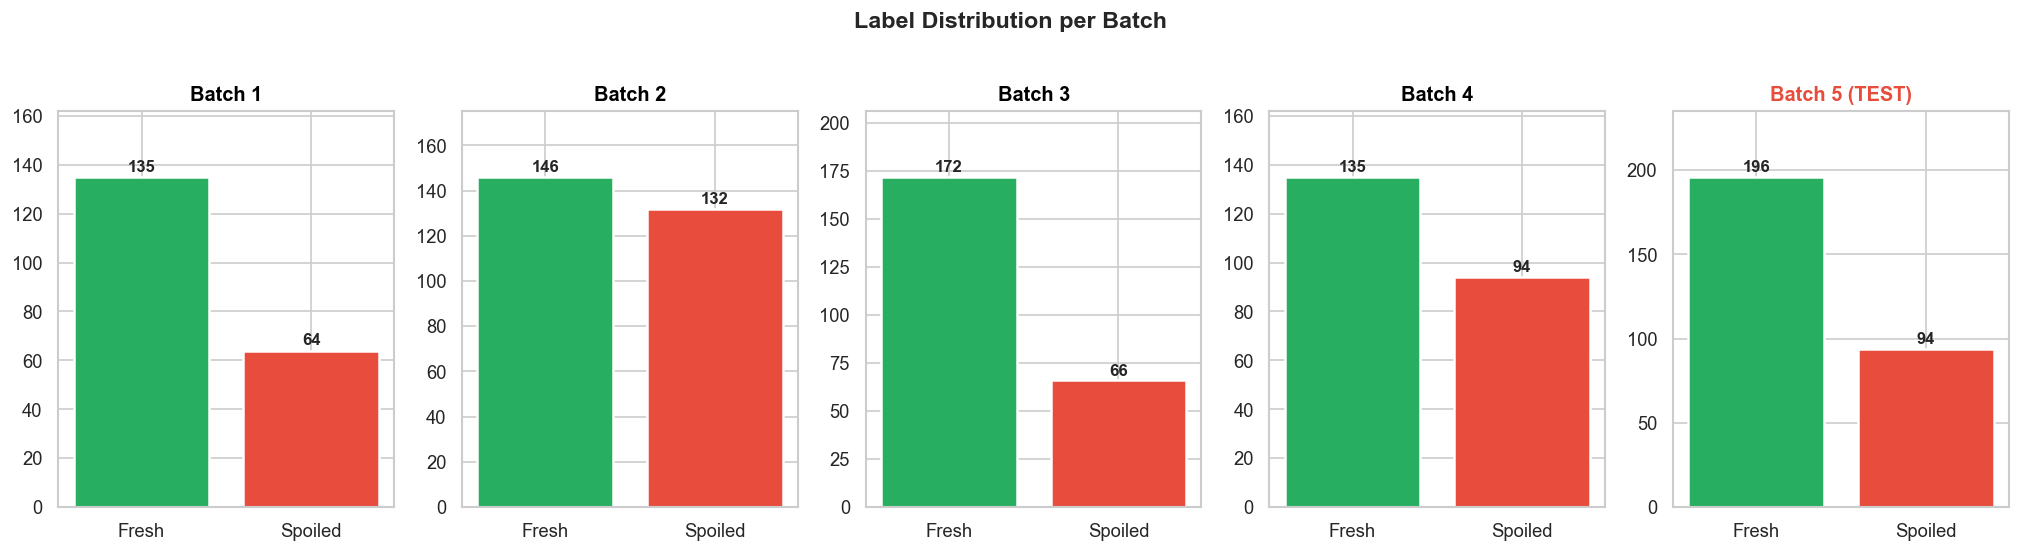

💡 Each batch records the Fresh → Spoiled lifecycle.


In [5]:
# ── Plot 1: Label distribution per batch ─────────────────────────────────────
batch_ids_all = sorted(batches.keys())
fig, axes = plt.subplots(1, len(batch_ids_all), figsize=(3.4*len(batch_ids_all), 4.5))
fig.suptitle("Label Distribution per Batch", fontsize=14, fontweight='bold', y=1.02)
if len(batch_ids_all) == 1:
    axes = [axes]

for ax, i in zip(axes, batch_ids_all):
    df2 = batches[i].copy()
    df2['label'] = df2['label'].str.replace('-', '_', regex=False)
    counts = df2['label'].value_counts().reindex(LABEL_ORDER).fillna(0)
    colors = [LABEL_COLORS[l] for l in LABEL_ORDER]
    bars = ax.bar(LABEL_ORDER, counts.values,
                  color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(f"Batch {i}" + (" (TEST)" if i == TEST_BATCH else ""),
                 fontweight='bold', color='#e74c3c' if i == TEST_BATCH else 'black')
    ax.set_ylim(0, counts.max() * 1.2 if counts.max() > 0 else 1)
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(int(val)), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_01_label_distribution.png', bbox_inches='tight')
plt.show()
print("💡 Each batch records the Fresh → Spoiled lifecycle.")


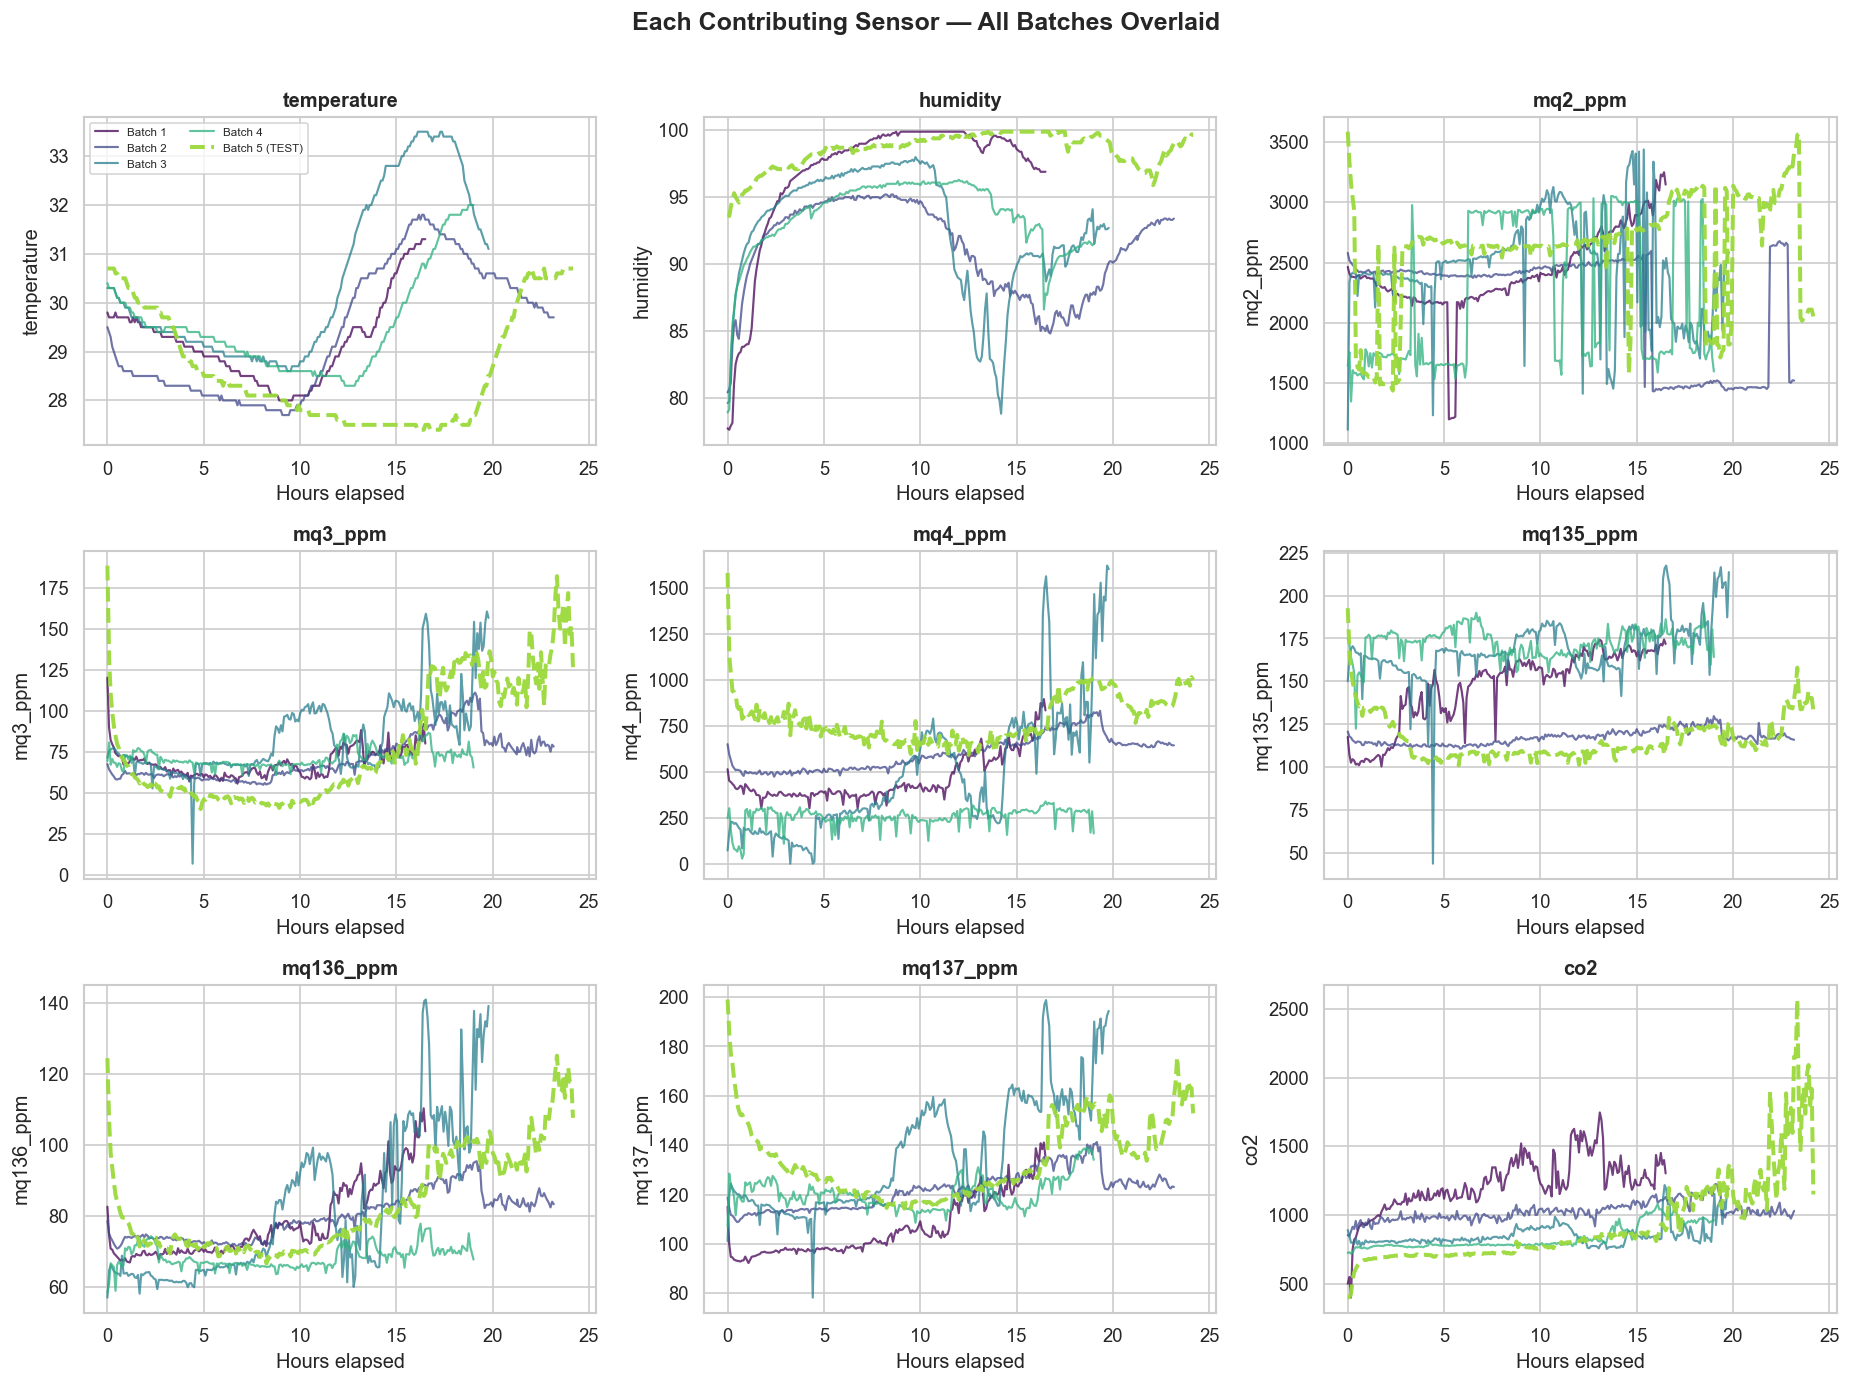

💡 Each panel is ONE sensor with ALL batches drawn together, so you can see
   whether that sensor rises/falls consistently across batches as rice spoils.
   The held-out TEST batch (dashed, thicker line) is highlighted for comparison.


In [6]:
# ── Plot 2: Contributing sensors — all batches overlaid (one graph per sensor) ─
# For each sensor (CO2, temperature, humidity, MQ gas sensors, ...), we draw
# ALL 5 batches on the SAME graph so you can compare how that sensor behaves
# batch-to-batch. The held-out TEST batch is drawn as a thicker dashed line.

batch_ids_all = sorted(batches.keys())
palette       = plt.cm.viridis(np.linspace(0, 0.85, len(batch_ids_all)))

ncols = 3
nrows = int(np.ceil(len(SENSOR_COLS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2*ncols, 3.8*nrows))
fig.suptitle("Each Contributing Sensor — All Batches Overlaid", fontsize=15, fontweight='bold', y=1.01)
axes = np.array(axes).flatten()

for idx, col in enumerate(SENSOR_COLS):
    ax = axes[idx]
    for color, batch_id in zip(palette, batch_ids_all):
        df2      = batches[batch_id]
        is_test  = (batch_id == TEST_BATCH)
        ax.plot(df2['hours_elapsed'], df2[col],
                color=color,
                linewidth=2.4 if is_test else 1.3,
                linestyle='--' if is_test else '-',
                alpha=0.95 if is_test else 0.75,
                label=f"Batch {batch_id}" + (" (TEST)" if is_test else ""))
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Hours elapsed')
    ax.set_ylabel(col)
    if idx == 0:
        ax.legend(fontsize=7, ncol=2)

# Hide any unused subplot slots
for j in range(len(SENSOR_COLS), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('plot_02_all_sensors_all_batches.png', bbox_inches='tight')
plt.show()
print("💡 Each panel is ONE sensor with ALL batches drawn together, so you can see")
print("   whether that sensor rises/falls consistently across batches as rice spoils.")
print("   The held-out TEST batch (dashed, thicker line) is highlighted for comparison.")


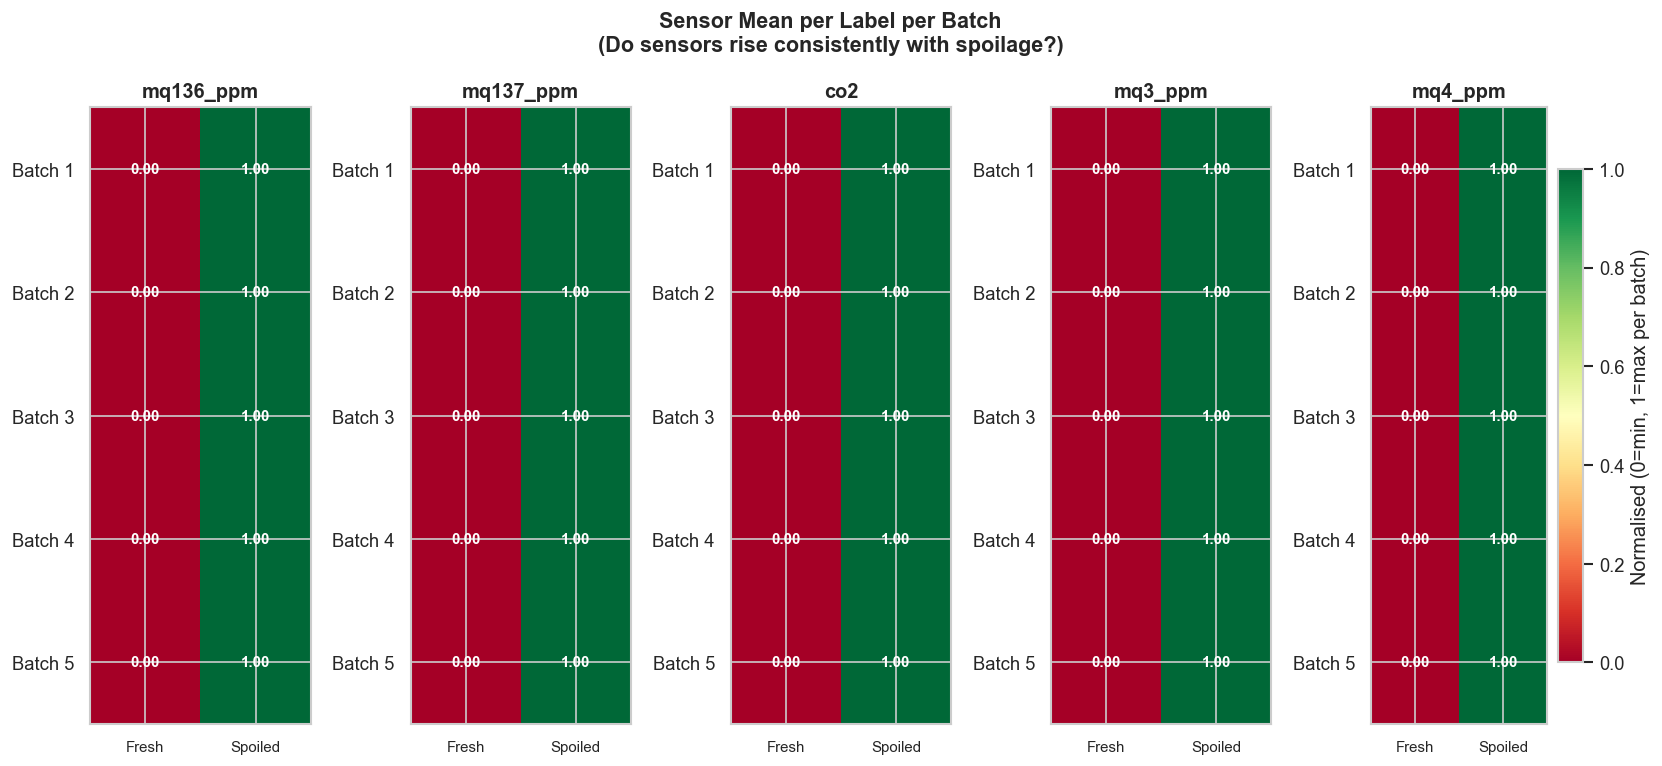

💡 GREEN (1.0) = highest reading in that batch.  RED (0.0) = lowest.
   Ideal: each row goes Red → Green as spoilage progresses (Fresh → Spoiled).


In [7]:
# ── Plot 3: Key sensor means per label × batch (heatmap-style) ──────────────
key_sensors  = ['mq136_ppm', 'mq137_ppm', 'co2', 'mq3_ppm', 'mq4_ppm']
batch_ids_all = sorted(all_data['batch'].unique())
n_batches_all = len(batch_ids_all)
n_labels      = len(LABEL_ORDER)

fig, axes = plt.subplots(1, len(key_sensors), figsize=(14, 1.1*n_batches_all + 1))
fig.suptitle("Sensor Mean per Label per Batch\n(Do sensors rise consistently with spoilage?)",
             fontsize=13, fontweight='bold')

for ax, col in zip(axes, key_sensors):
    pivot = all_data.groupby(['batch', 'label'])[col].mean().unstack().reindex(
        columns=LABEL_ORDER)
    # Normalize per-batch so we can compare shape across batches
    for batch_id in pivot.index:
        row = pivot.loc[batch_id]
        rng = row.max() - row.min()
        pivot.loc[batch_id] = (row - row.min()) / rng if rng > 0 else row

    im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(n_labels))
    ax.set_xticklabels(LABEL_ORDER, fontsize=9)
    ax.set_yticks(range(n_batches_all))
    ax.set_yticklabels([f'Batch {b}' for b in pivot.index])
    ax.set_title(col, fontweight='bold')
    for bi in range(n_batches_all):
        for li in range(n_labels):
            ax.text(li, bi, f'{pivot.iloc[bi, li]:.2f}', ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color='white' if pivot.iloc[bi,li] < 0.3 or pivot.iloc[bi,li] > 0.7 else 'black')

plt.colorbar(im, ax=axes[-1], shrink=0.8, label='Normalised (0=min, 1=max per batch)')
plt.tight_layout()
plt.savefig('plot_03_sensor_heatmap.png', bbox_inches='tight')
plt.show()
print("💡 GREEN (1.0) = highest reading in that batch.  RED (0.0) = lowest.")
print("   Ideal: each row goes Red → Green as spoilage progresses (Fresh → Spoiled).")


## 🚨 Step 3: Understanding Data Leakage

**Data leakage** is the most common and dangerous mistake in machine learning. It makes your model look excellent during development but fail in the real world.

### What is it?
> Leakage happens when information that wouldn't be available at prediction time accidentally enters the training process.

### The 3 types of leakage we guard against:

**1. Row leakage** — splitting rows randomly across batches
- ❌ Wrong: `train_test_split(all_data, test_size=0.2, random_state=42)`
- This gives Batch 5 data to the training set. The model memorises Batch 5 patterns, then "predicts" them perfectly. Useless in production.
- ✅ Right: Split by entire batches.

**2. Scaler leakage** — fitting `StandardScaler` on all data before splitting
- ❌ Wrong: `scaler.fit(all_data[features])` then splitting
- The scaler has learned the min/max/mean of the test batch. The test is no longer "unseen."
- ✅ Right: `scaler.fit(train_data_only)`, then `scaler.transform(test_data)`.

**3. Rolling feature leakage** — computing rolling averages across batch boundaries
- ❌ Wrong: rolling mean on the entire combined DataFrame (Batch 1's last reading leaks into Batch 2's first)
- ✅ Right: compute rolling features **within each batch independently**.

### Our strategy: Leave-One-Batch-Out (LOBO)

```
Training: Batches 1, 2, 3, 4  ──┐
                                 ├── Cross-validate with LOBO
                                 │   Fold 1: train on 2,3,4 → validate on 1
                                 │   Fold 2: train on 1,3,4 → validate on 2
                                 │   Fold 3: train on 1,2,4 → validate on 3
                                 │   Fold 4: train on 1,2,3 → validate on 4
                                 └── Train FINAL model on all 4 batches

Test: Batch 5 (locked) ─────────── Never seen until FINAL evaluation
```


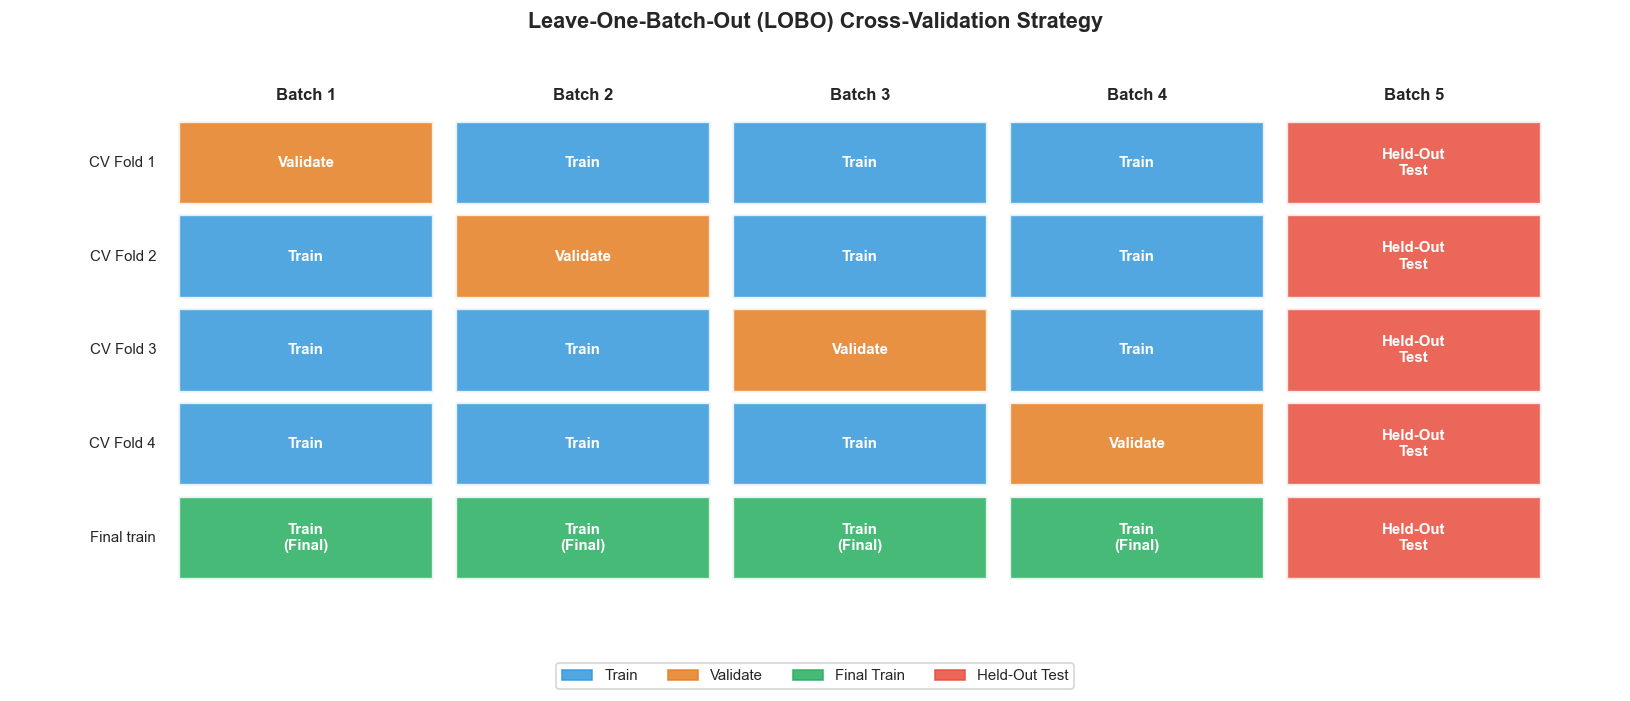

💡 Batch 5 appears ONLY in the 'Held-Out Test' column — never in any training or validation step.


In [8]:
# ── Visualise the LOBO strategy ──────────────────────────────────────────────
all_batch_ids   = sorted(batches.keys())
train_batch_ids = sorted([b for b in all_batch_ids if b != TEST_BATCH])

# Build the matrix: one row per CV fold, plus a final "train on everything" row
matrix    = []
row_names = []
for fold_i, val_b in enumerate(train_batch_ids, start=1):
    row = []
    for b in all_batch_ids:
        if b == TEST_BATCH:
            row.append('TEST')
        elif b == val_b:
            row.append('VAL')
        else:
            row.append('TRAIN')
    matrix.append(row)
    row_names.append(f'CV Fold {fold_i}')

final_row = ['TEST' if b == TEST_BATCH else 'FINAL' for b in all_batch_ids]
matrix.append(final_row)
row_names.append('Final train')

col_names = [f'Batch {b}' for b in all_batch_ids]
n_rows, n_cols = len(matrix), len(col_names)

fig, ax = plt.subplots(figsize=(2.75*n_cols, 0.9*n_rows + 1.5))
ax.axis('off')
ax.set_title("Leave-One-Batch-Out (LOBO) Cross-Validation Strategy",
             fontsize=13, fontweight='bold', pad=12)

colors_map  = {'TRAIN': '#3498db', 'VAL': '#e67e22', 'TEST': '#e74c3c', 'FINAL': '#27ae60'}
labels_text = {'TRAIN': 'Train', 'VAL': 'Validate', 'TEST': 'Held-Out\nTest', 'FINAL': 'Train\n(Final)'}

for row_i, row in enumerate(matrix):
    for col_j, role in enumerate(row):
        rect = plt.Rectangle([col_j*2.5, (n_rows-1-row_i)*0.9], 2.3, 0.8,
                              color=colors_map[role], alpha=0.85, ec='white', lw=2)
        ax.add_patch(rect)
        ax.text(col_j*2.5 + 1.15, (n_rows-1-row_i)*0.9 + 0.4,
                labels_text[role], ha='center', va='center',
                color='white', fontsize=9, fontweight='bold')

for col_j, cn in enumerate(col_names):
    ax.text(col_j*2.5 + 1.15, n_rows*0.9 + 0.15, cn, ha='center', va='center', fontsize=10, fontweight='bold')
for row_i, rn in enumerate(row_names):
    ax.text(-0.2, (n_rows-1-row_i)*0.9 + 0.4, rn, ha='right', va='center', fontsize=9)

patches = [mpatches.Patch(color=c, alpha=0.85, label=t.replace('\n', ' '))
           for c, t in [('#3498db','Train'),('#e67e22','Validate'),('#27ae60','Final Train'),('#e74c3c','Held-Out Test')]]
ax.legend(handles=patches, loc='upper center', fontsize=9, ncol=4,
          bbox_to_anchor=(0.5, -0.08))
ax.set_xlim(-1.5, 2.5*n_cols + 0.5)
ax.set_ylim(-0.3, n_rows*0.9 + 0.6)

plt.tight_layout()
plt.savefig('plot_04_lobo_strategy.png', bbox_inches='tight')
plt.show()
print(f"💡 Batch {TEST_BATCH} appears ONLY in the 'Held-Out Test' column — never in any training or validation step.")


## ⚙️ Step 4: Feature Engineering & Preprocessing

### What we compute:

**1. Rolling mean features** (`sensor_rm`)
Instead of just the current CO₂ reading, we also give the model the *average of the last 5 readings* (≈25 minutes). This smooths out noise and captures trends.

```
Raw CO₂:     [980, 1050, 970, 1020, 990, 1080, 1040]  ← noisy
Rolled mean: [980, 1015, 1000, 1005,  1002, 1018, 1022]  ← trend
```

**2. Remaining Shelf Life — RSL** (regression target only, NOT a feature!)
```
RSL = hours_when_batch_became_Spoiled − hours_elapsed_so_far
```
Example: Batch spoils at hour 12.
- At hour 3 → RSL = 9.0
- At hour 10 → RSL = 2.0
- At hour 14 → RSL = 0.0

⚠️ RSL is computed from labels, but it is only ever used as the **target** (what we predict), never as an input feature.

In [9]:
# ── Feature engineering functions ────────────────────────────────────────────

def add_rolling_features(df, window=ROLL_WIN):
    """
    Adds rolling mean of each sensor as extra features.

    ⚠️ ANTI-LEAKAGE: Rolling is computed within each batch independently.
    The window never looks backwards across batch boundaries.
    """
    result = []
    for batch_id in sorted(df['batch'].unique()):
        grp = df[df['batch'] == batch_id].copy().sort_values('timestamp_local')
        for col in SENSOR_COLS:
            # min_periods=1: use however many readings are available (handles batch start)
            grp[f'{col}_rm'] = grp[col].rolling(window=window, min_periods=1).mean()
        result.append(grp)
    return pd.concat(result).reset_index(drop=True)


def compute_rsl(df):
    """
    Computes Remaining Shelf Life (RSL) in hours per batch.

    RSL = max(0, spoilage_onset_hour - current_hour_elapsed)

    This is the REGRESSION TARGET. It uses the ground-truth labels to find
    when the batch became 'Spoiled', then counts down from there.
    The model will learn to predict this value from sensor readings alone.
    """
    result = []
    for batch_id in sorted(df['batch'].unique()):
        grp = df[df['batch'] == batch_id].copy()
        spoiled_times = grp[grp['label'] == 'Spoiled']['hours_elapsed']
        spoil_onset   = spoiled_times.min() if len(spoiled_times) > 0 else grp['hours_elapsed'].max()
        grp['rsl']    = np.maximum(0.0, spoil_onset - grp['hours_elapsed'])
        result.append(grp)
    return pd.concat(result).reset_index(drop=True)


# ── Apply to all data ─────────────────────────────────────
all_data = add_rolling_features(all_data)
all_data = compute_rsl(all_data)

# ── Define the feature columns for each model ─────────────
ROLL_COLS    = [f'{c}_rm' for c in SENSOR_COLS]          # 9 smoothed features

CLF_FEATURES = SENSOR_COLS + ROLL_COLS                   # 18 features for classifier
#   ↑ No 'hours_elapsed' — classifier must generalise across batches
#     that spoil at different absolute times

REG_FEATURES = SENSOR_COLS + ROLL_COLS + ['hours_elapsed']  # 19 features for regressor
#   ↑ Include 'hours_elapsed' — you always know how long the food has been out

print(f"Classifier features ({len(CLF_FEATURES)}):")
print(f"  {CLF_FEATURES}")
print(f"\nRegressor features ({len(REG_FEATURES)}):")
print(f"  {REG_FEATURES}")
print(f"\nRSL range across all data: {all_data['rsl'].min():.1f}h → {all_data['rsl'].max():.1f}h")
print(f"\nSample rows showing RSL:")
print(all_data[['batch','hours_elapsed','label','rsl']].iloc[[0,50,100,150,190]].to_string(index=False))

Classifier features (18):
  ['temperature', 'humidity', 'mq2_ppm', 'mq3_ppm', 'mq4_ppm', 'mq135_ppm', 'mq136_ppm', 'mq137_ppm', 'co2', 'temperature_rm', 'humidity_rm', 'mq2_ppm_rm', 'mq3_ppm_rm', 'mq4_ppm_rm', 'mq135_ppm_rm', 'mq136_ppm_rm', 'mq137_ppm_rm', 'co2_rm']

Regressor features (19):
  ['temperature', 'humidity', 'mq2_ppm', 'mq3_ppm', 'mq4_ppm', 'mq135_ppm', 'mq136_ppm', 'mq137_ppm', 'co2', 'temperature_rm', 'humidity_rm', 'mq2_ppm_rm', 'mq3_ppm_rm', 'mq4_ppm_rm', 'mq135_ppm_rm', 'mq136_ppm_rm', 'mq137_ppm_rm', 'co2_rm', 'hours_elapsed']

RSL range across all data: 0.0h → 16.3h

Sample rows showing RSL:
 batch  hours_elapsed   label       rsl
     1       0.000000   Fresh 11.250000
     1       4.166667   Fresh  7.083333
     1       8.333333   Fresh  2.916667
     1      12.500000 Spoiled  0.000000
     1      15.833333 Spoiled  0.000000


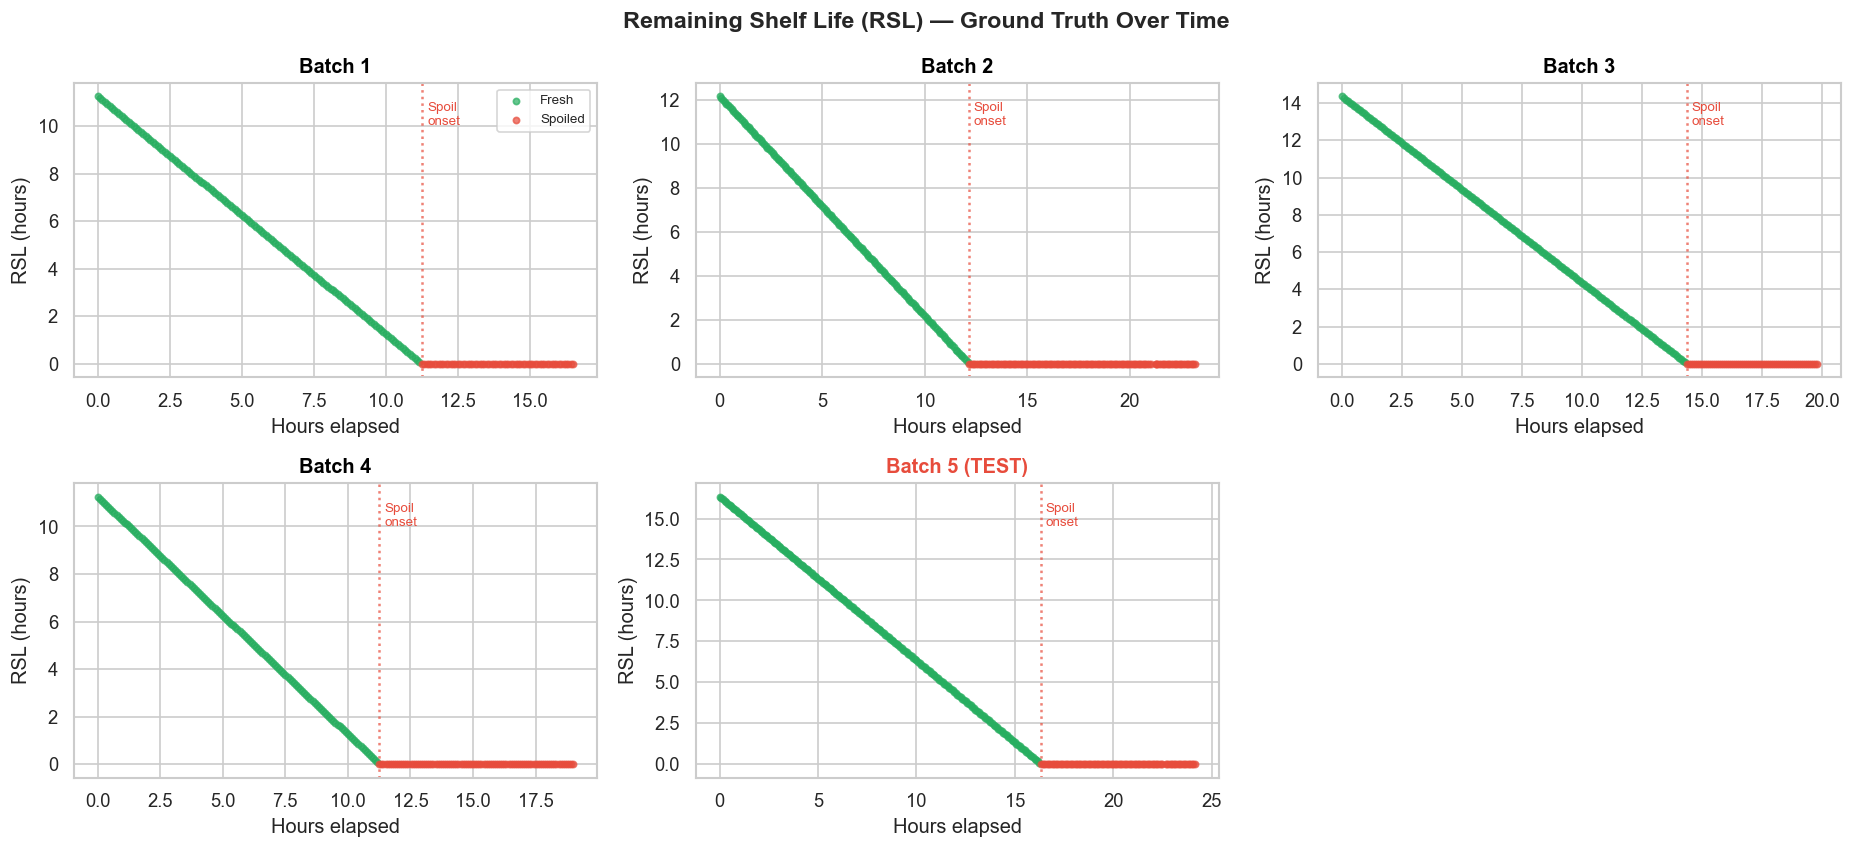

💡 RSL starts high and drops to 0 at the spoilage onset (dotted red line).
   After that point, all readings are labelled 'Spoiled' and RSL stays at 0.


In [10]:
# ── Plot 5: RSL over time for all batches ────────────────────────────────────
all_batch_ids = sorted(all_data['batch'].unique())
ncols = 3
nrows = int(np.ceil(len(all_batch_ids) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2*ncols, 3.6*nrows))
fig.suptitle("Remaining Shelf Life (RSL) — Ground Truth Over Time", fontsize=14, fontweight='bold')
axes = np.array(axes).flatten()

for idx, batch_id in enumerate(all_batch_ids):
    ax = axes[idx]
    df2 = all_data[all_data['batch'] == batch_id]
    for label, color in LABEL_COLORS.items():
        mask = df2['label'] == label
        ax.scatter(df2.loc[mask, 'hours_elapsed'], df2.loc[mask, 'rsl'],
                   color=color, s=14, alpha=0.7, label=label)
    ax.set_title(f"Batch {batch_id}" + (" (TEST)" if batch_id == TEST_BATCH else ""),
                 fontweight='bold', color='#e74c3c' if batch_id == TEST_BATCH else 'black')
    ax.set_xlabel('Hours elapsed')
    ax.set_ylabel('RSL (hours)')
    if idx == 0:
        ax.legend(fontsize=8)
    # Annotate spoilage onset
    spoil_onset = df2[df2['label']=='Spoiled']['hours_elapsed'].min()
    if pd.notna(spoil_onset):
        ax.axvline(spoil_onset, color='#e74c3c', linestyle=':', alpha=0.7)
        ax.text(spoil_onset + 0.2, ax.get_ylim()[1]*0.85, 'Spoil\nonset', fontsize=8, color='#e74c3c')

for j in range(len(all_batch_ids), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('plot_05_rsl_over_time.png', bbox_inches='tight')
plt.show()
print("💡 RSL starts high and drops to 0 at the spoilage onset (dotted red line).")
print("   After that point, all readings are labelled 'Spoiled' and RSL stays at 0.")


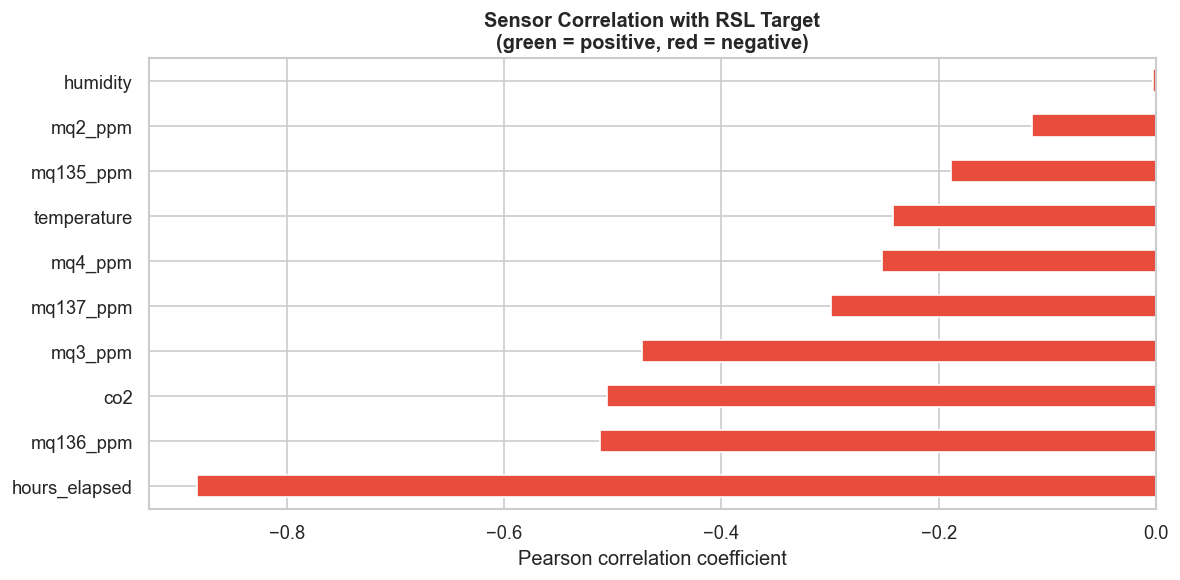

💡 Sensors with strong negative correlation (dark red bars) increase as RSL decreases.
   'hours_elapsed' has a very strong negative correlation — because RSL = spoil_onset − hours_elapsed.


In [11]:
# ── Plot 6: Feature correlation with RSL ─────────────────────────────────────
corr_with_rsl = all_data[SENSOR_COLS + ['hours_elapsed', 'rsl']].corr()['rsl'].drop('rsl').sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v < 0 else '#27ae60' for v in corr_with_rsl]
corr_with_rsl.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Sensor Correlation with RSL Target\n(green = positive, red = negative)",
             fontweight='bold')
ax.set_xlabel("Pearson correlation coefficient")
plt.tight_layout()
plt.savefig('plot_06_correlation_rsl.png', bbox_inches='tight')
plt.show()
print("💡 Sensors with strong negative correlation (dark red bars) increase as RSL decreases.")
print("   'hours_elapsed' has a very strong negative correlation — because RSL = spoil_onset − hours_elapsed.")

## ✂️ Step 5: Create Train / Test Split

**Batch 5 is locked away right now.** It will not be touched until Step 8 (final evaluation).

```
train_df  ←  Batches 1, 2, 3, 4  (used for LOBO CV + final model training)
test_df   ←  Batch 5             (used ONLY at the end, for the true test score)
```


In [12]:
# ── Create the split ─────────────────────────────────────────────────────────
train_df = all_data[all_data['batch'] != TEST_BATCH].copy().reset_index(drop=True)
test_df  = all_data[all_data['batch'] == TEST_BATCH].copy().reset_index(drop=True)

le = LabelEncoder()
le.fit(LABEL_ORDER)     # encode: Fresh=0, Spoiled=1

print(f"Training set  → {len(train_df):>4} rows  |  Batches: {sorted(train_df['batch'].unique())}")
print(f"Test set      → {len(test_df):>4} rows  |  Batch:   [{TEST_BATCH}]  ← LOCKED")
print(f"\nLabel encoder mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"\nTrain label distribution:")
print(train_df['label'].value_counts().reindex(LABEL_ORDER).to_string())
print(f"\nTest label distribution:")
print(test_df['label'].value_counts().reindex(LABEL_ORDER).to_string())


Training set  →  944 rows  |  Batches: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Test set      →  290 rows  |  Batch:   [5]  ← LOCKED

Label encoder mapping: {np.str_('Fresh'): np.int64(0), np.str_('Spoiled'): np.int64(1)}

Train label distribution:
label
Fresh      588
Spoiled    356

Test label distribution:
label
Fresh      196
Spoiled     94


## 🤖 Step 6: Model 1 — Status Classifier (Random Forest)

### What is a Random Forest?
Imagine asking 200 different experts (decision trees) to look at the sensor readings and each vote on whether the rice is Fresh or Spoiled. The majority vote wins. Each tree was trained on a slightly different random subset of the data, so they disagree in useful ways — and their combined vote is more reliable than any single tree.

### Training phase overview:
1. **LOBO Cross-Validation** → estimate real-world accuracy using only training batches (1–4)
2. **Train final model** on all 4 training batches
3. **Evaluate on Batch 5** → the true test score


In [13]:
# ── LOBO Cross-Validation — Classifier ───────────────────────────────────────
print("=" * 60)
print("  LOBO Cross-Validation — Status Classifier")
print("=" * 60)

val_batches     = sorted(train_df['batch'].unique())
lobo_clf_scores = []

for val_batch in val_batches:
    # ── Split this fold ──────────────────────────────────
    tr = train_df[train_df['batch'] != val_batch]
    vl = train_df[train_df['batch'] == val_batch]

    X_tr  = tr[CLF_FEATURES];  y_tr  = le.transform(tr['label'])
    X_val = vl[CLF_FEATURES];  y_val = le.transform(vl['label'])

    # ── Scale: fit on training fold only ──────────────────
    # ⚠️ ANTI-LEAKAGE: scaler sees ONLY the training fold
    sc = StandardScaler()
    X_tr_sc  = sc.fit_transform(X_tr)
    X_val_sc = sc.transform(X_val)        # ← uses train statistics

    # ── Train and evaluate ────────────────────────────────
    clf = RandomForestClassifier(n_estimators=200, min_samples_leaf=2,
                                 random_state=SEED, n_jobs=-1)
    clf.fit(X_tr_sc, y_tr)
    preds_val = clf.predict(X_val_sc)
    acc = accuracy_score(y_val, preds_val)
    lobo_clf_scores.append(acc)

    print(f"\n  Fold — validate on Batch {val_batch}  |  Accuracy: {acc*100:.1f}%")
    print(classification_report(y_val, preds_val, target_names=le.classes_, digits=3, zero_division=0))

cv_mean = np.mean(lobo_clf_scores)
cv_std  = np.std(lobo_clf_scores)
print("=" * 60)
print(f"  LOBO CV Accuracy:  {cv_mean*100:.1f}% ± {cv_std*100:.1f}%")
print("=" * 60)
print()
print("📌 Note: Accuracy varies between folds because each batch has slightly")
print("   different sensor characteristics. This is normal with small datasets.")
print("   More batches would reduce this variance.")

  LOBO Cross-Validation — Status Classifier

  Fold — validate on Batch 1  |  Accuracy: 82.4%
              precision    recall  f1-score   support

       Fresh      0.794     1.000     0.885       135
     Spoiled      1.000     0.453     0.624        64

    accuracy                          0.824       199
   macro avg      0.897     0.727     0.754       199
weighted avg      0.860     0.824     0.801       199


  Fold — validate on Batch 2  |  Accuracy: 92.8%
              precision    recall  f1-score   support

       Fresh      0.880     1.000     0.936       146
     Spoiled      1.000     0.848     0.918       132

    accuracy                          0.928       278
   macro avg      0.940     0.924     0.927       278
weighted avg      0.937     0.928     0.927       278


  Fold — validate on Batch 3  |  Accuracy: 73.9%
              precision    recall  f1-score   support

       Fresh      1.000     0.640     0.780       172
     Spoiled      0.516     1.000     0.680

In [14]:
# ── Train FINAL classifier on ALL training data ───────────────────────────────
print("Training final classifier on batches", sorted(train_df['batch'].unique()), "...")

X_train_clf = train_df[CLF_FEATURES]
y_train_clf = le.transform(train_df['label'])

# Fit scaler on ALL training data (no test data included)
scaler_clf      = StandardScaler()
X_train_clf_sc  = scaler_clf.fit_transform(X_train_clf)

final_clf = RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                   random_state=SEED, n_jobs=-1)
final_clf.fit(X_train_clf_sc, y_train_clf)

print(f"✅ Classifier trained!")
print(f"   Input features  : {len(CLF_FEATURES)}")
print(f"   Training samples: {len(X_train_clf_sc)}")
print(f"   Number of trees : {final_clf.n_estimators}")

Training final classifier on batches [np.int64(1), np.int64(2), np.int64(3), np.int64(4)] ...
✅ Classifier trained!
   Input features  : 18
   Training samples: 944
   Number of trees : 300


In [15]:
# ── FINAL EVALUATION on the held-out test batch ──────────────────────────────
print("=" * 60)
print(f"  FINAL TEST — Status Classifier on Batch {TEST_BATCH}")
print("=" * 60)

# ⚠️ ANTI-LEAKAGE: apply the scaler fitted on training data
X_test_clf    = test_df[CLF_FEATURES]
X_test_clf_sc = scaler_clf.transform(X_test_clf)   # NOT fit_transform!
y_test_clf    = le.transform(test_df['label'])

y_pred_clf = final_clf.predict(X_test_clf_sc)
test_acc   = accuracy_score(y_test_clf, y_pred_clf)

print(f"\nTest Accuracy: {test_acc*100:.1f}%")
print()
print(classification_report(y_test_clf, y_pred_clf, target_names=le.classes_, digits=3, zero_division=0))
print()
print("📌 INTERPRETING THESE RESULTS:")
print("   - Precision: Of all readings predicted as X, what % are truly X?")
print("   - Recall:    Of all truly-X readings, what % did we correctly predict as X?")
print("   - F1-score:  Harmonic mean of precision and recall (balanced metric)")


  FINAL TEST — Status Classifier on Batch 5

Test Accuracy: 82.4%

              precision    recall  f1-score   support

       Fresh      0.840     0.913     0.875       196
     Spoiled      0.779     0.638     0.702        94

    accuracy                          0.824       290
   macro avg      0.810     0.776     0.789       290
weighted avg      0.821     0.824     0.819       290


📌 INTERPRETING THESE RESULTS:
   - Precision: Of all readings predicted as X, what % are truly X?
   - Recall:    Of all truly-X readings, what % did we correctly predict as X?
   - F1-score:  Harmonic mean of precision and recall (balanced metric)


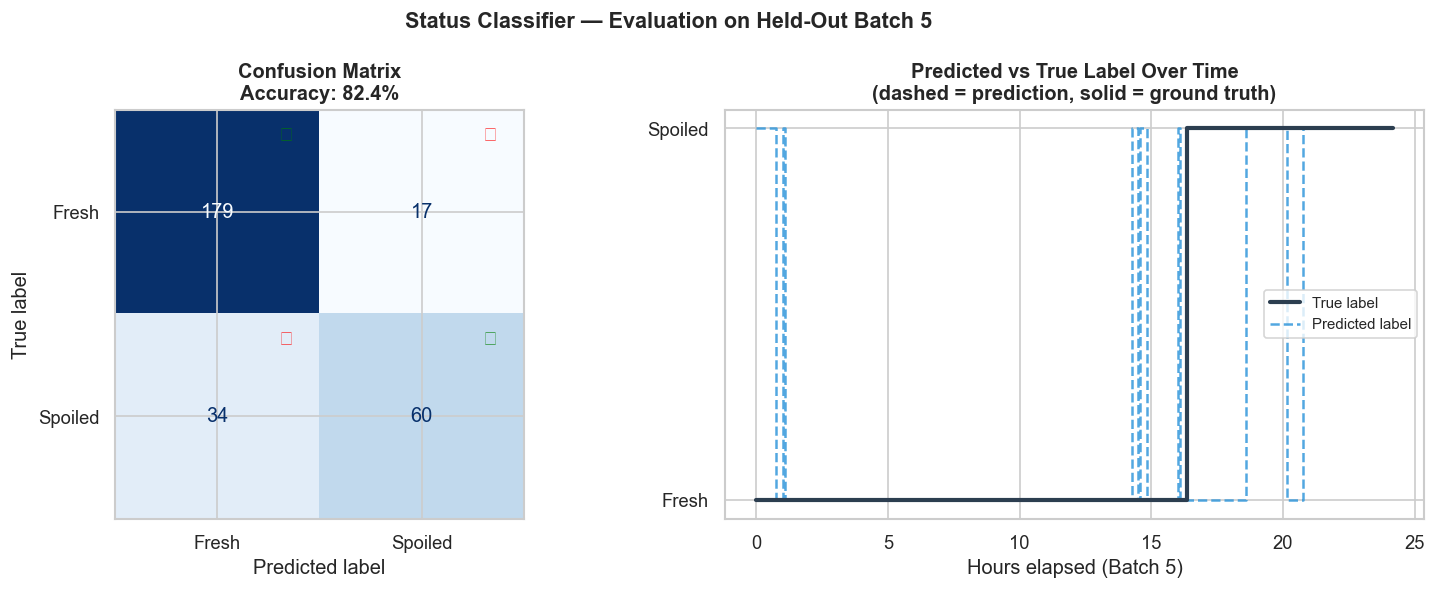

Correct: 239/290 readings  |  Wrong: 51/290 readings


In [16]:
# ── Plot 7: Confusion Matrix + Predictions Over Time ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Status Classifier — Evaluation on Held-Out Batch {TEST_BATCH}", fontsize=13, fontweight='bold')

n_classes = len(LABEL_ORDER)

# Confusion matrix
cm   = confusion_matrix(y_test_clf, y_pred_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix\nAccuracy: {test_acc*100:.1f}%', fontweight='bold')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

# Annotation: diagonal = correct, off-diagonal = wrong
for i in range(n_classes):
    for j in range(n_classes):
        color = 'green' if i == j else 'red'
        axes[0].text(j + 0.3, i - 0.35, '✓' if i==j else '✗',
                     color=color, fontsize=12, fontweight='bold')

# Predictions over time
df_pred = test_df.copy()
df_pred['pred_label'] = le.inverse_transform(y_pred_clf)
df_pred['correct']    = (df_pred['label'] == df_pred['pred_label'])

# True label steps
ax = axes[1]
label_num = {l: i for i, l in enumerate(LABEL_ORDER)}
ax.step(df_pred['hours_elapsed'],
        [label_num[l] for l in df_pred['label']],
        where='post', color='#2c3e50', linewidth=2.5, label='True label', zorder=3)
ax.step(df_pred['hours_elapsed'],
        [label_num[l] for l in df_pred['pred_label']],
        where='post', color='#3498db', linewidth=1.5, linestyle='--',
        alpha=0.85, label='Predicted label', zorder=2)
ax.set_yticks(range(n_classes))
ax.set_yticklabels(LABEL_ORDER)
ax.set_xlabel(f'Hours elapsed (Batch {TEST_BATCH})')
ax.set_title('Predicted vs True Label Over Time\n(dashed = prediction, solid = ground truth)',
             fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('plot_07_classifier_eval.png', bbox_inches='tight')
plt.show()

wrong = int((~df_pred['correct']).sum())
right = int(df_pred['correct'].sum())
print(f"Correct: {right}/{len(df_pred)} readings  |  Wrong: {wrong}/{len(df_pred)} readings")


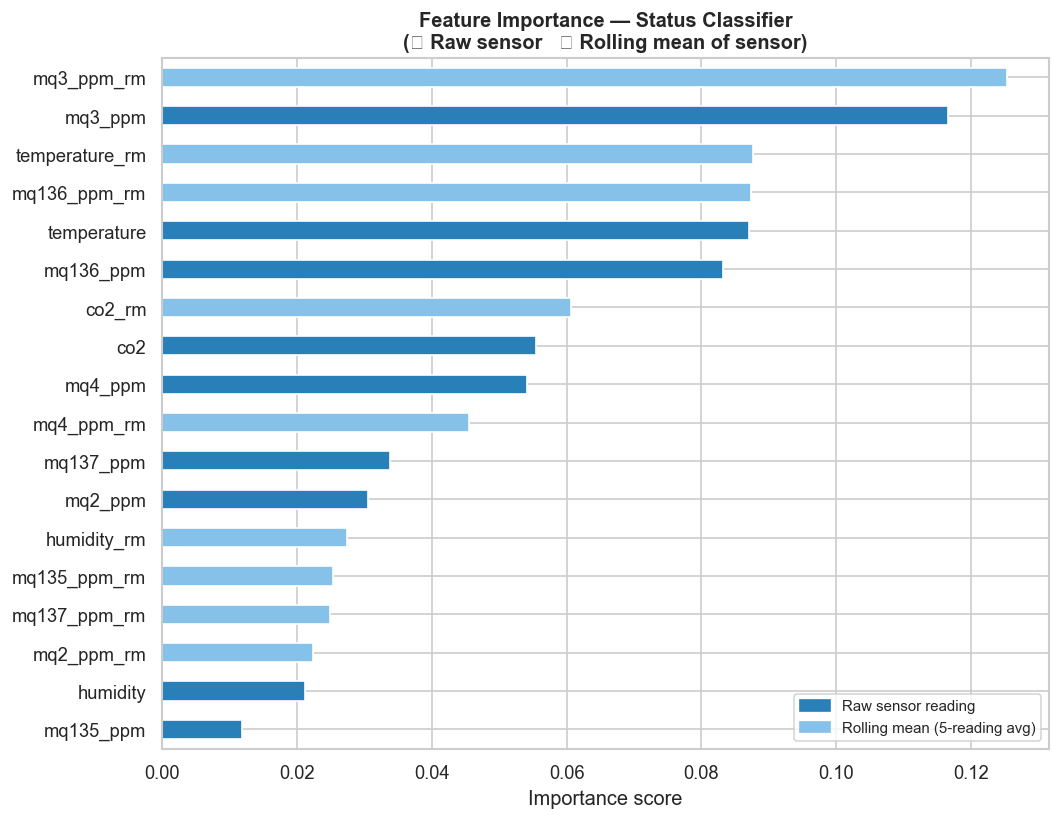

💡 Taller bars = the model relies on that feature more for its decisions.
   If a raw sensor AND its rolling mean are both important, that sensor is highly informative.


In [17]:
# ── Plot 8: Classifier Feature Importance ────────────────────────────────────
imp_clf = pd.Series(final_clf.feature_importances_, index=CLF_FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#85c1e9' if '_rm' in n else '#2980b9' for n in imp_clf.index]
imp_clf.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title("Feature Importance — Status Classifier\n"
             "(🔵 Raw sensor   🔹 Rolling mean of sensor)", fontweight='bold')
ax.set_xlabel('Importance score')

# Legend
patches = [mpatches.Patch(color='#2980b9', label='Raw sensor reading'),
           mpatches.Patch(color='#85c1e9', label='Rolling mean (5-reading avg)')]
ax.legend(handles=patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('plot_08_clf_importance.png', bbox_inches='tight')
plt.show()
print("💡 Taller bars = the model relies on that feature more for its decisions.")
print("   If a raw sensor AND its rolling mean are both important, that sensor is highly informative.")

In [18]:
# ── Save classifier models ────────────────────────────────────────────────────
joblib.dump(final_clf,  'classifier.pkl')
joblib.dump(scaler_clf, 'scaler_clf.pkl')
joblib.dump(le,         'label_encoder.pkl')

print("✅ Classifier files saved:")
print("   📄 classifier.pkl      — the trained Random Forest model")
print("   📄 scaler_clf.pkl      — StandardScaler fitted on training data")
print("   📄 label_encoder.pkl   — maps 0/1 → Fresh/Spoiled")
print()
print("How to use in your dashboard:")
print("─" * 55)
print('''  import joblib, numpy as np

  clf    = joblib.load('classifier.pkl')
  scaler = joblib.load('scaler_clf.pkl')
  le     = joblib.load('label_encoder.pkl')

  # sensor_readings: list of 18 values (9 raw + 9 rolling means)
  scaled  = scaler.transform([sensor_readings])
  encoded = clf.predict(scaled)[0]          # e.g. 0
  status  = le.inverse_transform([encoded])[0]  # e.g. 'Fresh'
  print(status)''')


✅ Classifier files saved:
   📄 classifier.pkl      — the trained Random Forest model
   📄 scaler_clf.pkl      — StandardScaler fitted on training data
   📄 label_encoder.pkl   — maps 0/1 → Fresh/Spoiled

How to use in your dashboard:
───────────────────────────────────────────────────────
  import joblib, numpy as np

  clf    = joblib.load('classifier.pkl')
  scaler = joblib.load('scaler_clf.pkl')
  le     = joblib.load('label_encoder.pkl')

  # sensor_readings: list of 18 values (9 raw + 9 rolling means)
  scaled  = scaler.transform([sensor_readings])
  encoded = clf.predict(scaled)[0]          # e.g. 0
  status  = le.inverse_transform([encoded])[0]  # e.g. 'Fresh'
  print(status)


## 📈 Step 7: Model 2 — RSL Regressor (Random Forest)

### What is a Regressor?
Same Random Forest idea, but instead of voting for a **category** (Fresh/Half/Spoiled), the trees each estimate a **number** (e.g., 8.3 hours), and the final prediction is the average of all trees' estimates.

### Evaluation metrics for regression:

| Metric | Meaning | Good if... |
|--------|---------|-----------|
| **MAE** | Average error in hours | Low (< 2h ideal) |
| **RMSE** | Like MAE but large errors count more | Low |
| **R²** | % of variance explained | Close to 1.0 |

> An R² of 0.95 means the model explains 95% of the variation in RSL — the remaining 5% is noise or factors the sensors can't capture.

In [20]:
# ── LOBO Cross-Validation — RSL Regressor ────────────────────────────────────
print("=" * 60)
print("  LOBO Cross-Validation — RSL Regressor")
print("=" * 60)

lobo_reg_scores = []

for val_batch in val_batches:
    tr = train_df[train_df['batch'] != val_batch]
    vl = train_df[train_df['batch'] == val_batch]

    X_tr  = tr[REG_FEATURES];   y_tr  = tr['rsl']
    X_val = vl[REG_FEATURES];   y_val = vl['rsl']

    sc = StandardScaler()
    X_tr_sc  = sc.fit_transform(X_tr)
    X_val_sc = sc.transform(X_val)

    reg = RandomForestRegressor(n_estimators=200, min_samples_leaf=3,
                                random_state=SEED, n_jobs=-1)
    reg.fit(X_tr_sc, y_tr)

    preds = np.maximum(0, reg.predict(X_val_sc))   # RSL can't be negative
    mae   = mean_absolute_error(y_val, preds)
    rmse  = np.sqrt(mean_squared_error(y_val, preds))
    r2    = r2_score(y_val, preds)
    lobo_reg_scores.append({'mae': mae, 'rmse': rmse, 'r2': r2})

    print(f"\n  Fold — validate on Batch {val_batch}")
    print(f"  MAE  = {mae:.2f}h  (avg, prediction is off by {mae:.2f} hours)")
    print(f"  RMSE = {rmse:.2f}h")
    print(f"  R²   = {r2:.3f}")

print()
print("=" * 60)
print(f"  LOBO CV Mean MAE:  {np.mean([x['mae'] for x in lobo_reg_scores]):.2f}h")
print(f"  LOBO CV Mean RMSE: {np.mean([x['rmse'] for x in lobo_reg_scores]):.2f}h")
print(f"  LOBO CV Mean R²:   {np.mean([x['r2'] for x in lobo_reg_scores]):.3f}")
print("=" * 60)

  LOBO Cross-Validation — RSL Regressor

  Fold — validate on Batch 1
  MAE  = 1.26h  (avg, prediction is off by 1.26 hours)
  RMSE = 1.75h
  R²   = 0.783

  Fold — validate on Batch 2
  MAE  = 0.89h  (avg, prediction is off by 0.89 hours)
  RMSE = 1.06h
  R²   = 0.929

  Fold — validate on Batch 3
  MAE  = 1.94h  (avg, prediction is off by 1.94 hours)
  RMSE = 2.37h
  R²   = 0.755

  Fold — validate on Batch 4
  MAE  = 2.55h  (avg, prediction is off by 2.55 hours)
  RMSE = 2.87h
  R²   = 0.413

  LOBO CV Mean MAE:  1.66h
  LOBO CV Mean RMSE: 2.01h
  LOBO CV Mean R²:   0.720


In [21]:
# ── Train FINAL regressor on ALL training data ───────────────────────────────
print("Training final RSL regressor on batches", sorted(train_df['batch'].unique()), "...")

X_train_reg    = train_df[REG_FEATURES]
y_train_reg    = train_df['rsl']

scaler_reg     = StandardScaler()
X_train_reg_sc = scaler_reg.fit_transform(X_train_reg)

final_reg = RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                  random_state=SEED, n_jobs=-1)
final_reg.fit(X_train_reg_sc, y_train_reg)

print(f"✅ RSL Regressor trained!")
print(f"   Input features  : {len(REG_FEATURES)}")
print(f"   Training samples: {len(X_train_reg_sc)}")

Training final RSL regressor on batches [np.int64(1), np.int64(2), np.int64(3), np.int64(4)] ...
✅ RSL Regressor trained!
   Input features  : 19
   Training samples: 944


In [22]:
# ── FINAL EVALUATION on the held-out test batch ──────────────────────────────
print("=" * 60)
print(f"  FINAL TEST — RSL Regressor on Batch {TEST_BATCH}")
print("=" * 60)

X_test_reg    = test_df[REG_FEATURES]
X_test_reg_sc = scaler_reg.transform(X_test_reg)
y_test_reg    = test_df['rsl']

y_pred_reg = np.maximum(0, final_reg.predict(X_test_reg_sc))

mae_test  = mean_absolute_error(y_test_reg, y_pred_reg)
rmse_test = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2_test   = r2_score(y_test_reg, y_pred_reg)

print(f"\n  Test MAE:  {mae_test:.2f} hours")
print(f"  Test RMSE: {rmse_test:.2f} hours")
print(f"  Test R²:   {r2_test:.3f}")
print()
total_shelf_life = test_df['hours_elapsed'].max()
print(f"  Batch {TEST_BATCH} total shelf life: {total_shelf_life:.1f}h")
print(f"  Avg error ({mae_test:.2f}h) = {mae_test/total_shelf_life*100:.1f}% of total shelf life")


  FINAL TEST — RSL Regressor on Batch 5

  Test MAE:  2.48 hours
  Test RMSE: 3.17 hours
  Test R²:   0.663

  Batch 5 total shelf life: 24.2h
  Avg error (2.48h) = 10.3% of total shelf life


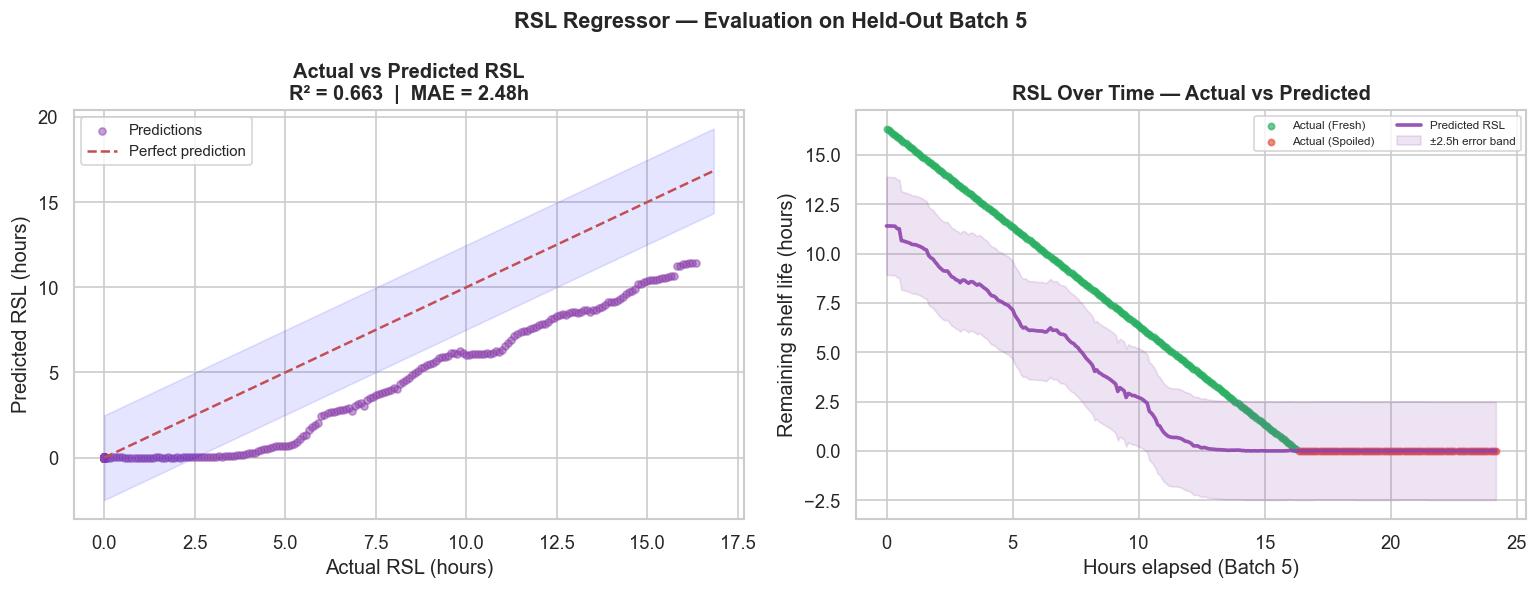

In [23]:
# ── Plot 9: Predicted vs Actual RSL ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"RSL Regressor — Evaluation on Held-Out Batch {TEST_BATCH}", fontsize=13, fontweight='bold')

# Scatter: actual vs predicted
ax = axes[0]
ax.scatter(y_test_reg, y_pred_reg, alpha=0.5, color='#8e44ad', s=18, label='Predictions')
max_val = max(float(y_test_reg.max()), float(y_pred_reg.max())) + 0.5
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual RSL (hours)')
ax.set_ylabel('Predicted RSL (hours)')
ax.set_title(f'Actual vs Predicted RSL\nR² = {r2_test:.3f}  |  MAE = {mae_test:.2f}h', fontweight='bold')
ax.legend(fontsize=9)
# Error band
ax.fill_between([0, max_val], [mae_test, max_val+mae_test], [-mae_test, max_val-mae_test],
                alpha=0.1, color='blue', label=f'±{mae_test:.1f}h band')

# RSL over time
ax = axes[1]
df_rsl = test_df.copy()
df_rsl['pred_rsl'] = y_pred_reg
for label, color in LABEL_COLORS.items():
    mask = df_rsl['label'] == label
    ax.scatter(df_rsl.loc[mask, 'hours_elapsed'], df_rsl.loc[mask, 'rsl'],
               color=color, s=14, alpha=0.65, label=f'Actual ({label})')
ax.plot(df_rsl['hours_elapsed'], df_rsl['pred_rsl'],
        color='#8e44ad', linewidth=2.2, alpha=0.9, label='Predicted RSL', zorder=5)
ax.fill_between(df_rsl['hours_elapsed'],
                df_rsl['pred_rsl'] - mae_test, df_rsl['pred_rsl'] + mae_test,
                alpha=0.15, color='#8e44ad', label=f'±{mae_test:.1f}h error band')
ax.set_xlabel(f'Hours elapsed (Batch {TEST_BATCH})')
ax.set_ylabel('Remaining shelf life (hours)')
ax.set_title('RSL Over Time — Actual vs Predicted', fontweight='bold')
ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig('plot_09_regressor_eval.png', bbox_inches='tight')
plt.show()


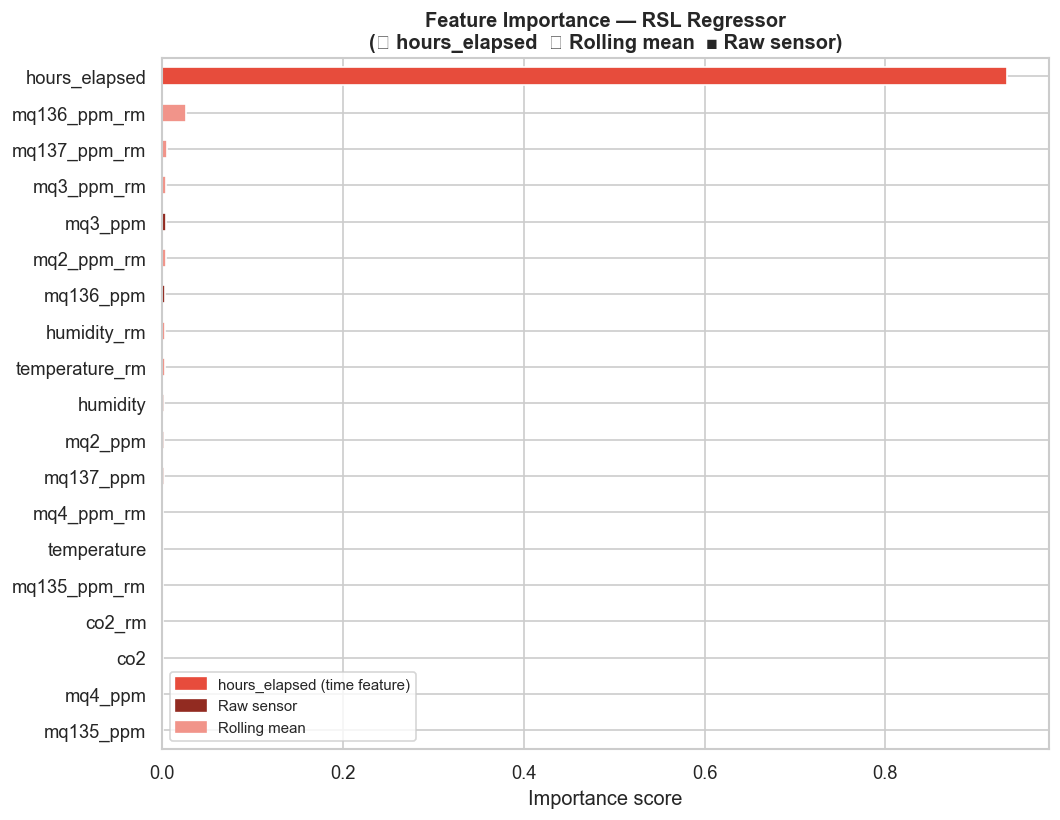

💡 If 'hours_elapsed' dominates: the model relies heavily on time.
   Ideally, sensors should also contribute — confirming biological changes.


In [24]:
# ── Plot 10: RSL Regressor Feature Importance ─────────────────────────────────
imp_reg = pd.Series(final_reg.feature_importances_, index=REG_FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#e74c3c' if n == 'hours_elapsed' else
          ('#f1948a' if '_rm' in n else '#922b21')
          for n in imp_reg.index]
imp_reg.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title("Feature Importance — RSL Regressor\n"
             "(🔴 hours_elapsed  🟥 Rolling mean  ■ Raw sensor)", fontweight='bold')
ax.set_xlabel('Importance score')
patches = [mpatches.Patch(color='#e74c3c', label='hours_elapsed (time feature)'),
           mpatches.Patch(color='#922b21', label='Raw sensor'),
           mpatches.Patch(color='#f1948a', label='Rolling mean')]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.savefig('plot_10_reg_importance.png', bbox_inches='tight')
plt.show()
print("💡 If 'hours_elapsed' dominates: the model relies heavily on time.")
print("   Ideally, sensors should also contribute — confirming biological changes.")

In [25]:
# ── Save regressor models ─────────────────────────────────────────────────────
joblib.dump(final_reg,  'regressor.pkl')
joblib.dump(scaler_reg, 'scaler_reg.pkl')

print("✅ Regressor files saved:")
print("   📄 regressor.pkl       — the trained RSL regression model")
print("   📄 scaler_reg.pkl      — StandardScaler for regression features")
print()
print("How to use in your dashboard:")
print("─" * 55)
print("""  import joblib, numpy as np

  reg    = joblib.load('regressor.pkl')
  scaler = joblib.load('scaler_reg.pkl')

  # sensor_readings_with_time: 19 values
  # (9 raw sensors + 9 rolling means + hours_elapsed)
  scaled        = scaler.transform([sensor_readings_with_time])
  hours_left    = max(0, reg.predict(scaled)[0])
  print(f\"{hours_left:.1f} hours remaining\")""")

✅ Regressor files saved:
   📄 regressor.pkl       — the trained RSL regression model
   📄 scaler_reg.pkl      — StandardScaler for regression features

How to use in your dashboard:
───────────────────────────────────────────────────────
  import joblib, numpy as np

  reg    = joblib.load('regressor.pkl')
  scaler = joblib.load('scaler_reg.pkl')

  # sensor_readings_with_time: 19 values
  # (9 raw sensors + 9 rolling means + hours_elapsed)
  scaled        = scaler.transform([sensor_readings_with_time])
  hours_left    = max(0, reg.predict(scaled)[0])
  print(f"{hours_left:.1f} hours remaining")


## 🔴 Step 8: Real-Time Dashboard Simulation

This simulates exactly what your deployed system will do: receive sensor readings every 5 minutes, smooth them, predict status + RSL, and display both on the dashboard.

The **stability buffer** prevents the badge from flickering: the status only changes when **3 consecutive readings** agree on the new label.

In [26]:
# ── Real-time prediction simulation on Batch 4 ───────────────────────────────
sim = test_df.sort_values('hours_elapsed').reset_index(drop=True).copy()

# ── Apply smoothing (same window as training) ─────────────────────────────────
for col in SENSOR_COLS:
    sim[f'{col}_rm'] = sim[col].rolling(window=ROLL_WIN, min_periods=1).mean()

# ── Classifier predictions (raw) ──────────────────────────────────────────────
X_sim_clf_sc = scaler_clf.transform(sim[CLF_FEATURES])
raw_preds     = le.inverse_transform(final_clf.predict(X_sim_clf_sc))

# ── Stability buffer: only flip status after 3 consecutive agreement ───────────
STABILITY = 3
stable_preds = []
current      = raw_preds[0]
buffer       = [raw_preds[0]]

for pred in raw_preds[1:]:
    if pred == current:
        buffer = [pred]
    else:
        buffer.append(pred)
        if len(buffer) >= STABILITY and len(set(buffer[-STABILITY:])) == 1:
            current = pred
            buffer  = [pred]
    stable_preds.append(current)
stable_preds.insert(0, raw_preds[0])

sim['raw_pred']    = raw_preds
sim['stable_pred'] = stable_preds

# ── RSL predictions ───────────────────────────────────────────────────────────
X_sim_reg_sc  = scaler_reg.transform(sim[REG_FEATURES])
sim['pred_rsl'] = np.maximum(0, final_reg.predict(X_sim_reg_sc))

suppressed = sum(r != s for r, s in zip(raw_preds, stable_preds))
print(f"✅ Simulation complete — {len(sim)} readings processed")
print(f"   Raw prediction flips suppressed by stability buffer: {suppressed}")

✅ Simulation complete — 290 readings processed
   Raw prediction flips suppressed by stability buffer: 15


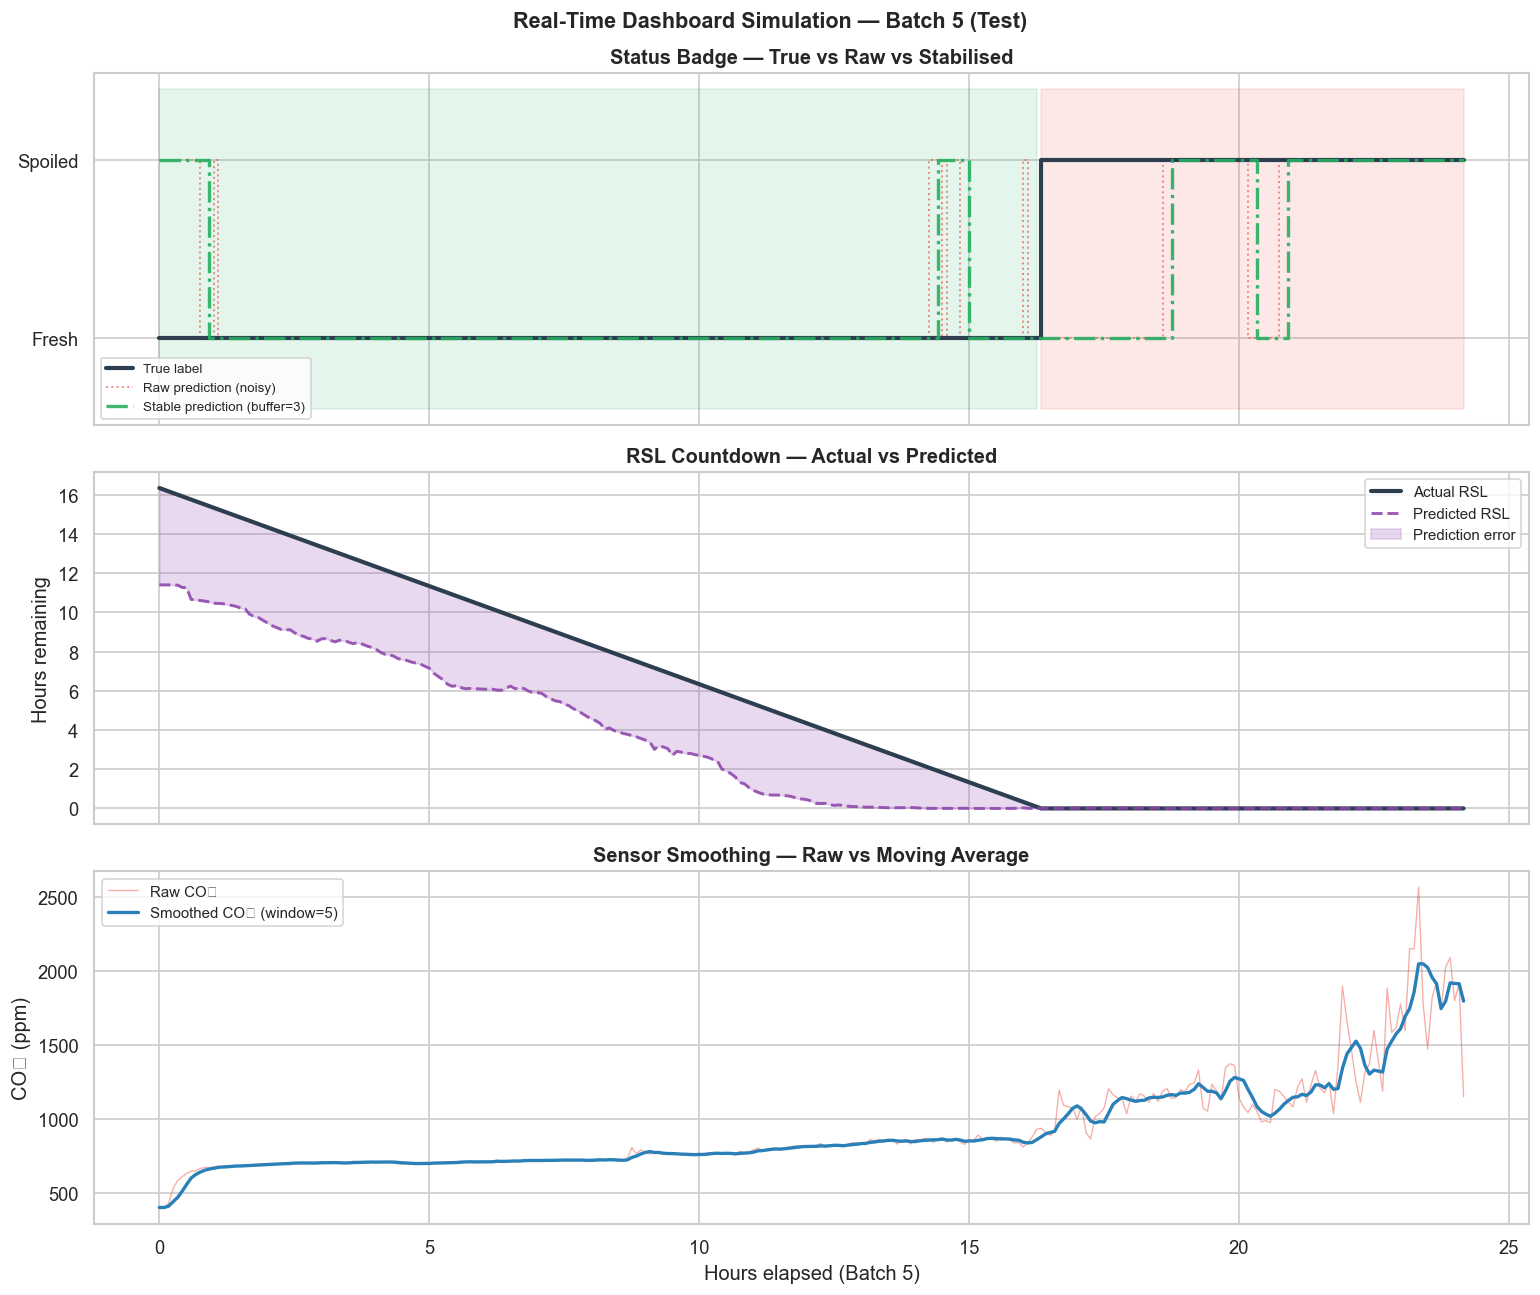

In [27]:
# ── Plot 11: Full dashboard simulation ───────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
fig.suptitle(f"Real-Time Dashboard Simulation — Batch {TEST_BATCH} (Test)", fontsize=13, fontweight='bold')

n_classes = len(LABEL_ORDER)
label_num = {l: i for i, l in enumerate(LABEL_ORDER)}
label_colors_list = [LABEL_COLORS[l] for l in LABEL_ORDER]

# Panel 1: Status classification
ax = axes[0]
# Shade background by true label
for label, color in LABEL_COLORS.items():
    mask = sim['label'] == label
    if mask.any():
        ax.fill_between(sim['hours_elapsed'], -0.4, n_classes - 0.6, where=mask,
                        alpha=0.12, color=color)
ax.step(sim['hours_elapsed'], [label_num[l] for l in sim['label']],
        where='post', color='#2c3e50', linewidth=2.5, label='True label', zorder=3)
ax.step(sim['hours_elapsed'], [label_num[l] for l in sim['raw_pred']],
        where='post', color='#e74c3c', linewidth=1.2, linestyle=':',
        alpha=0.6, label='Raw prediction (noisy)', zorder=2)
ax.step(sim['hours_elapsed'], [label_num[l] for l in sim['stable_pred']],
        where='post', color='#27ae60', linewidth=2, linestyle='-.',
        alpha=0.9, label=f'Stable prediction (buffer={STABILITY})', zorder=4)
ax.set_yticks(range(n_classes))
ax.set_yticklabels(LABEL_ORDER)
ax.set_title('Status Badge — True vs Raw vs Stabilised', fontweight='bold')
ax.legend(fontsize=8, loc='lower left')

# Panel 2: RSL countdown
ax = axes[1]
ax.plot(sim['hours_elapsed'], sim['rsl'], color='#2c3e50', linewidth=2.5,
        label='Actual RSL', zorder=3)
ax.plot(sim['hours_elapsed'], sim['pred_rsl'], color='#8e44ad', linewidth=1.8,
        linestyle='--', alpha=0.85, label='Predicted RSL', zorder=4)
ax.fill_between(sim['hours_elapsed'], sim['rsl'], sim['pred_rsl'],
                alpha=0.2, color='#8e44ad', label='Prediction error')
ax.set_ylabel('Hours remaining')
ax.set_title('RSL Countdown — Actual vs Predicted', fontweight='bold')
ax.legend(fontsize=9)

# Panel 3: CO2 raw vs smoothed
ax = axes[2]
ax.plot(sim['hours_elapsed'], sim['co2'], color='#e74c3c', linewidth=0.8,
        alpha=0.45, label='Raw CO₂')
ax.plot(sim['hours_elapsed'], sim['co2_rm'], color='#2980b9', linewidth=2,
        label=f'Smoothed CO₂ (window={ROLL_WIN})')
ax.set_xlabel(f'Hours elapsed (Batch {TEST_BATCH})')
ax.set_ylabel('CO₂ (ppm)')
ax.set_title('Sensor Smoothing — Raw vs Moving Average', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('plot_11_realtime_simulation.png', bbox_inches='tight')
plt.show()


## 📋 Step 9: Your Complete Training & Testing Guide

---

### 🟢 How to TRAIN — Step by Step

**Training** means showing the algorithm thousands of (sensor readings, correct answer) pairs and letting it adjust its internal rules until it gets them right. With Random Forest, this means growing many decision trees.

```
1. Collect batch .xlsx files → place them in your data/ folder
   data/
     cooked_rice_batch01.xlsx   ← train
     cooked_rice_batch02.xlsx   ← train
     cooked_rice_batch03.xlsx   ← train
     cooked_rice_batch04.xlsx   ← train
     cooked_rice_batch05.xlsx   ← held-out TEST

2. Open this notebook in Jupyter:
   pip install jupyterlab
   jupyter lab
   → Open rice_shelf_life_ml.ipynb

3. Run ALL cells in order (Shift+Enter on each)
   The notebook will:
   ✅ Load and explore all 5 batches            (Steps 2–3)
   ✅ Engineer features (rolling, RSL)          (Step 4)
   ✅ Lock Batch 5 away as the test set         (Step 5)
   ✅ Run LOBO CV on batches 1–4                (Steps 6–7)
   ✅ Train final models on batches 1–4         (Steps 6–7)
   ✅ Evaluate on held-out Batch 5               (Steps 6–7)
   ✅ Simulate real-time operation              (Step 8)
   ✅ Save: classifier.pkl, regressor.pkl,
            scaler_clf.pkl, scaler_reg.pkl,
            label_encoder.pkl                   (Steps 6–7)

4. Check LOBO CV scores before trusting the final test score.
   If CV accuracy and test accuracy are similar → model is consistent.
   If test is much lower than CV → the model may not generalise well.

5. When you get a 6th batch:
   → Add it to data/ folder
   → Decide whether it becomes the new TEST_BATCH, or joins training
     (e.g. keep TEST_BATCH = 5, and just add batch 6 to the training pool)
   → Re-run the whole notebook
```

---

### 🔵 How to TEST — Step by Step

**Testing** is different from training. Testing means evaluating the model on data it was never trained on, to measure real-world performance honestly.

```
There are two types of testing:

TYPE A — Offline testing (what this notebook does)
  → You have a full labelled batch (e.g., Batch 5)
  → Load the saved .pkl models (don't retrain)
  → Run predictions on all readings
  → Compare predictions to true labels
  → Compute accuracy, MAE, R², etc.

TYPE B — Real-time testing (dashboard / deployment)
  → Sensor readings arrive live, one every 5 minutes
  → Apply rolling mean to last 5 readings
  → Call: status = classifier.predict(smoothed_reading)
  → Call: rsl    = regressor.predict(smoothed_reading + hours_elapsed)
  → Display on dashboard

Pseudo-code for deployment:
─────────────────────────────────────────────
  import joblib, numpy as np
  from collections import deque

  clf      = joblib.load('classifier.pkl')
  reg      = joblib.load('regressor.pkl')
  sc_clf   = joblib.load('scaler_clf.pkl')
  sc_reg   = joblib.load('scaler_reg.pkl')
  le       = joblib.load('label_encoder.pkl')

  SENSORS     = ['temperature','humidity','mq2_ppm','mq3_ppm','mq4_ppm',
                 'mq135_ppm','mq136_ppm','mq137_ppm','co2']
  window_size = 5
  buffers     = {s: deque(maxlen=window_size) for s in SENSORS}
  batch_start = None

  def on_new_reading(sensor_dict, timestamp):
      global batch_start
      if batch_start is None:
          batch_start = timestamp
      hours_elapsed = (timestamp - batch_start).total_seconds() / 3600

      for s in SENSORS:
          buffers[s].append(sensor_dict[s])

      raw   = [sensor_dict[s]       for s in SENSORS]   # 9 values
      means = [np.mean(buffers[s])  for s in SENSORS]   # 9 rolling means

      clf_features = raw + means                         # 18 features
      reg_features = raw + means + [hours_elapsed]       # 19 features

      status = le.inverse_transform(
          clf.predict(sc_clf.transform([clf_features]))
      )[0]
      rsl    = max(0, reg.predict(sc_reg.transform([reg_features]))[0])

      return status, rsl
─────────────────────────────────────────────
```

---

### 📏 What the Metrics Mean

| Metric | Model | Meaning | Target for this project |
|--------|-------|---------|------------------------|
| **Accuracy** | Classifier | % of readings labelled correctly | ≥ 70% with 5 batches |
| **Precision** | Classifier | Of predicted Spoiled, how many truly are? | High (avoid false alarms) |
| **Recall** | Classifier | Of truly Spoiled, how many did we catch? | High (don't miss spoilage) |
| **MAE** | Regressor | Average error in hours | < 2 hours |
| **R²** | Regressor | % of variance explained | > 0.8 |

> **About the classifier accuracy:** With only 5 batches, accuracy may still vary between batches — some batches show much larger sensor separation between Fresh and Spoiled than others. This is not a bug — it is an honest reflection of how much data you have. **Adding more batches** will improve this significantly.

---

### ⚠️ The Golden Rules of ML

```
1. NEVER evaluate on training data.
   A model tested on its own training data looks perfect — 
   because it memorised the answers. Always test on held-out batches.

2. NEVER fit the scaler on test data.
   scaler.fit_transform(test_data) ← WRONG
   scaler.transform(test_data)     ← CORRECT (use fit from training)

3. NEVER compute rolling features across batch boundaries.
   The 5-reading window for Batch 2 must not include any readings from Batch 1.

4. Keep adding batches.
   5 batches = proof of concept. 20+ batches = robust system.
   Every new batch improves both models.
```


## ✅ Step 10: Summary & Files Produced

### What was built

| | Status Classifier | RSL Regressor |
|---|---|---|
| **Purpose** | Predict label (Fresh/Spoiled) | Predict hours until spoilage |
| **Algorithm** | Random Forest Classifier | Random Forest Regressor |
| **Features** | 18 (9 raw + 9 rolling means) | 19 (same + hours_elapsed) |
| **Validation** | LOBO CV on batches 1–4 | LOBO CV on batches 1–4 |
| **Test batch** | Batch 5 (held-out) | Batch 5 (held-out) |
| **Model file** | `classifier.pkl` | `regressor.pkl` |
| **Scaler file** | `scaler_clf.pkl` | `scaler_reg.pkl` |

### Files in your folder after running this notebook

```
📄 classifier.pkl       ← load with joblib, call .predict()
📄 regressor.pkl        ← load with joblib, call .predict()
📄 scaler_clf.pkl       ← apply BEFORE classifier predictions
📄 scaler_reg.pkl       ← apply BEFORE regressor predictions
📄 label_encoder.pkl    ← converts 0/1 → text labels

🖼️ plot_01_label_distribution.png
🖼️ plot_02_all_sensors_all_batches.png
🖼️ plot_03_sensor_heatmap.png
🖼️ plot_04_lobo_strategy.png
🖼️ plot_05_rsl_over_time.png
🖼️ plot_06_correlation_rsl.png
🖼️ plot_07_classifier_eval.png
🖼️ plot_08_clf_importance.png
🖼️ plot_09_regressor_eval.png
🖼️ plot_10_reg_importance.png
🖼️ plot_11_realtime_simulation.png
```

### Recommended next steps

1. **Add Batch 6** — place it in `data/`, decide whether to expand training or replace the test batch, re-run
2. **Connect to your dashboard** — use the deployment pseudo-code from Step 9
3. **Monitor production** — log predictions and compare to actual spoilage outcomes
4. **Recalibrate when accuracy drops** — sensor drift can degrade model performance over months
